In [1]:
!pip install imbalanced-learn --quiet

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm

from warnings import filterwarnings
filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from collections import Counter

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))

primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [18]:
url = "https://drive.google.com/uc?id=14SeeHaRiTcMYMRYMXSgY9IDHjc_MAE7N"
df = pd.read_csv(url, encoding='latin-1')

print("Shape data:", df.shape)
df.head()

Shape data: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [51]:
#EDA

print("Rows & Columns:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nNum duplicates:", df.duplicated().sum())

print("\nMissing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))

Rows & Columns: (172765, 27)

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour', 'Profitability Flag']

Num duplicates: 0

Missing values (top 20):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer Country                 0
Customer Segment                 0
Department Name                  0
order date (DateOrders)          0
Order Ite

In [52]:
#CLEANING

columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

# hapus shipping canceled
df = df[df['Delivery Status'] != 'Shipping canceled'].copy()

# ubah tanggal
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

print("Rows & Columns setelah cleaning:", df.shape)

print("\nMissing values (top 5):")
print(df.isna().sum().sort_values(ascending=False).head(5))

Rows & Columns setelah cleaning: (172765, 27)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [53]:
#FEATURE ENGINEERING

df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0, 'Profit',
    np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even')
)

df[['Order Processing Time', 'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour', 'Profitability Flag']].head()

,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitability Flag
0,3,-1,False,1,Wednesday,22,Profit
1,5,1,True,1,Saturday,12,Loss
2,4,0,False,1,Saturday,12,Loss
3,3,-1,False,1,Saturday,11,Profit
4,2,-2,False,1,Saturday,11,Profit


In [54]:
#Hasil Feature engineering

print(df['Is_Delayed'].value_counts())
print()
print(df['Profitability Flag'].value_counts())

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64


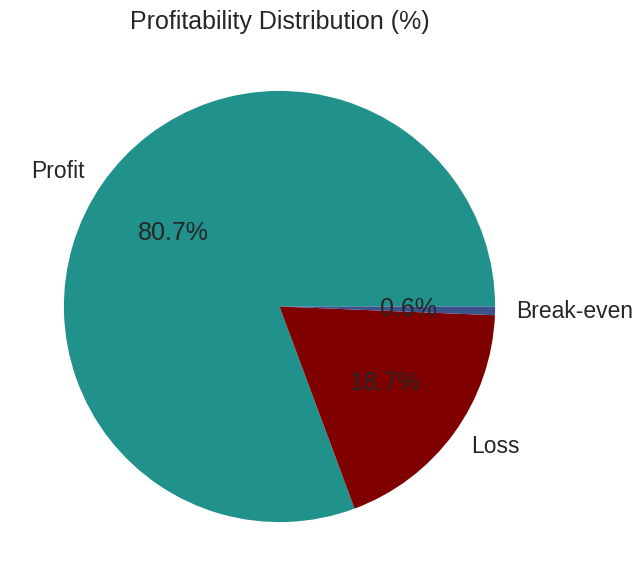

In [55]:
#PROFITABILITY DISTRIBUTION PIE CHART

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [56]:
#KPI

def format_money_text(value):
    if value >= 1e6:
        return f"{value/1e6:.1f}M $"
    elif value >= 1e3:
        return f"{value/1e3:.1f}K $"
    else:
        return f"{value:.0f} $"

delayed_df = df[df['Delay'] > 0].copy()

metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['Late Delivery (%)'] = (metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['On-time Delivery (%)'] = (1 - metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['Total Profit'] = df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
metrics['Profit at Risk'] = df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum()
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['Avg Order Profit'] = df['Order Profit Per Order'].mean()

print("=== Business KPIs ===\n")
print(f"Total Orders          : {metrics['Total Orders']:,}")
print(f"Late Deliveries       : {metrics['Late Deliveries']:,}")
print(f"Late Delivery %       : {metrics['Late Delivery (%)']:.2f}%")
print(f"On-Time Delivery %    : {metrics['On-time Delivery (%)']:.2f}%")
print(f"Total Profit          : {format_money_text(metrics['Total Profit'])}")
print(f"Profit at Risk        : {format_money_text(metrics['Profit at Risk'])}")
print(f"90th Percentile Delay : {metrics['90% Delay (days)']:.0f} days")
print(f"Avg Order Profit      : ${metrics['Avg Order Profit']:.2f}")

=== Business KPIs ===

Total Orders          : 172,765
Late Deliveries       : 94,523
Late Delivery %       : 54.71%
On-Time Delivery %    : 45.29%
Total Profit          : 7.5M $
Profit at Risk        : 2.1M $
90th Percentile Delay : 3 days
Avg Order Profit      : $22.03


In [57]:
#PROFIT METRICS

profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

profit_metrics.head(10)

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [58]:
#DELAY DISTRIBUTION PERSEN

delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index()
    * 100
).reset_index()

delay_distribution.columns = ['Delay Days', 'Percentage']
delay_distribution.head(10)

,Delay Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay Days,Percentage
0,-2,12.08
1,-1,11.99
2,0,21.21
3,1,30.97
4,2,15.95
5,3,3.92
6,4,3.88


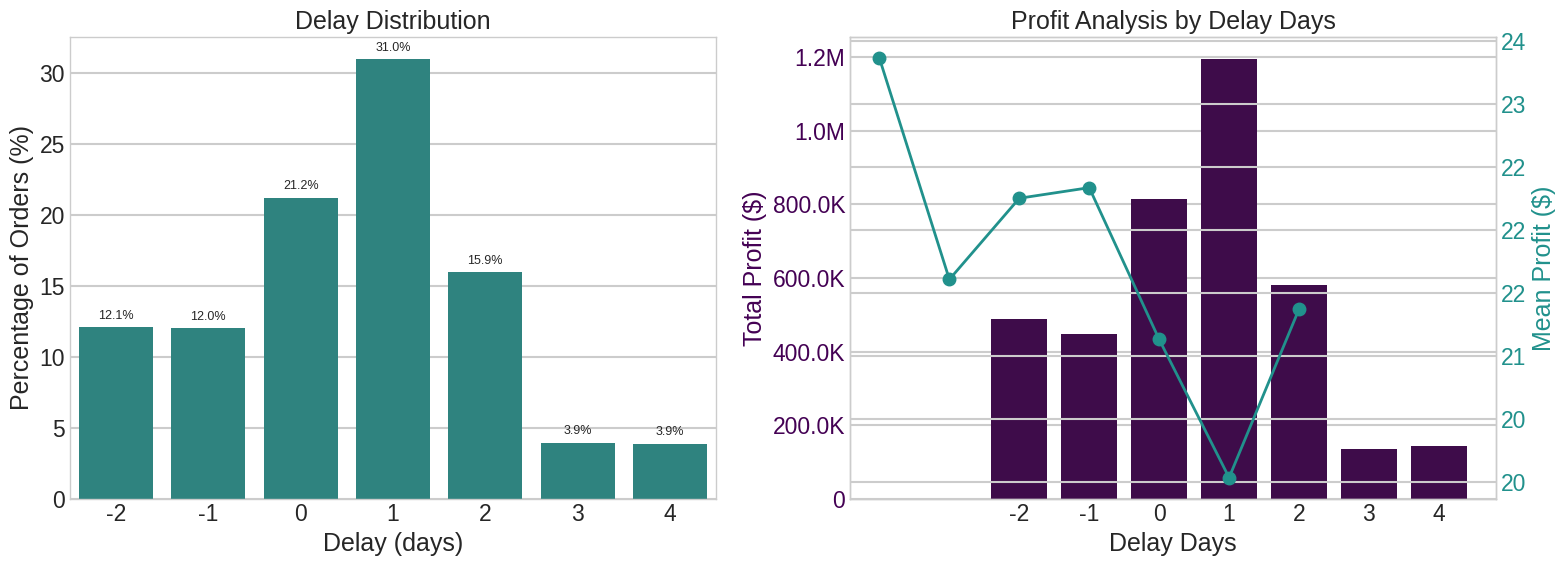

In [59]:
#Delay Distribution + Profit Analysis by Delay Days

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# kiri: delay distribution
sns.barplot(
    x='Delay Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of Orders (%)')

for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.4,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# kanan: total profit + mean profit
sns.barplot(
    x='Delay',
    y='total_profit',
    data=profit_metrics,
    color=primary_color,
    ax=ax2
)

ax2.set_title('Profit Analysis by Delay Days')
ax2.set_xlabel('Delay Days')
ax2.set_ylabel('Total Profit ($)', color=primary_color)
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()
ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    color=accent_color,
    linewidth=2
)
ax3.set_ylabel('Mean Profit ($)', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

def money_axis(value, tick_number):
    if abs(value) >= 1e6:
        return f'{value/1e6:.1f}M'
    elif abs(value) >= 1e3:
        return f'{value/1e3:.1f}K'
    else:
        return f'{value:.0f}'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(money_axis))
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(money_axis))

plt.tight_layout()
plt.show()

In [60]:
#Bottleneck detection helper

def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (cat_df['late_orders'] / cat_df['total_orders']) * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

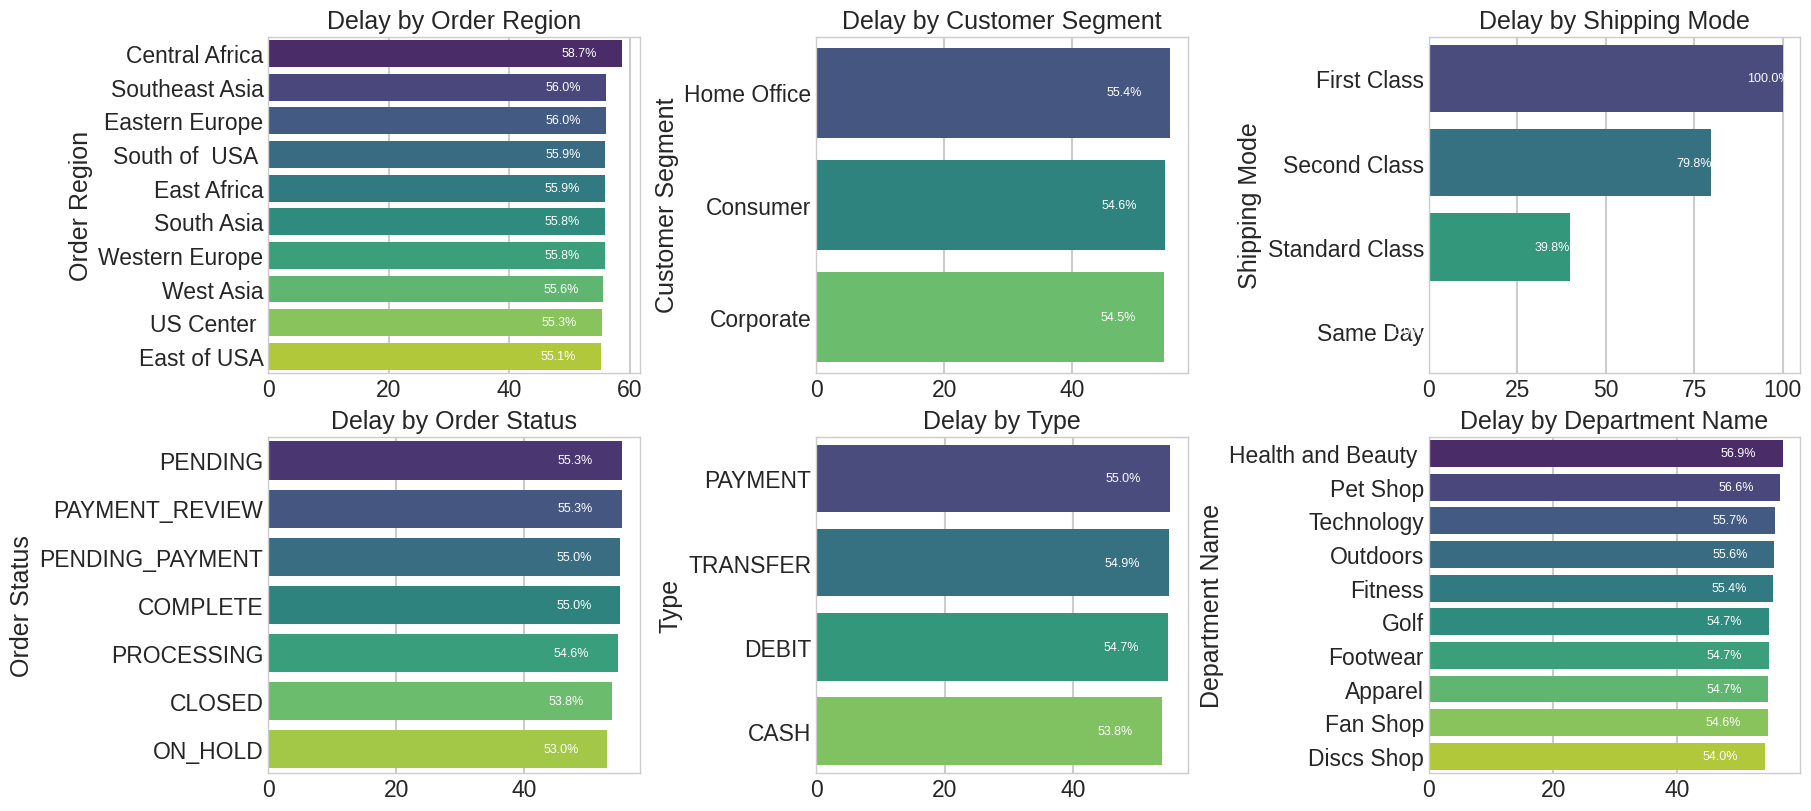

In [61]:
#Bottleneck Detection 6 kategori

categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 10,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=9,
            color='white'
        )

plt.show()

In [62]:
#Lihat hasil kategori tertentu

compute_delay_pct_by_category('Shipping Mode')

,Shipping Mode,total_orders,late_orders,delay_pct
0,First Class,26513,26513,100.000000
2,Second Class,33806,26987,79.829024
3,Standard Class,103153,41023,39.769081
1,Same Day,9293,0,0.000000


In [63]:
#Root cause analysis helper

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = (temp['late_orders'] / temp['total_orders']) * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    final_df = pd.concat(all_factors, ignore_index=True)
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    return top_factors

,Driver,Factor_Level,delay_pct,avg_delay,total_orders
0,Shipping Mode,Shipping Mode : First Class,100.00,1.00,278
2,Shipping Mode,Shipping Mode : Second Class,82.82,2.13,291
20,Order Status,Order Status : PAYMENT_REVIEW,80.00,1.20,20
21,Order Status,Order Status : PENDING,69.15,0.57,188
15,Type,Type : PAYMENT,63.58,0.76,346
16,Type,Type : TRANSFER,63.26,0.61,411
22,Order Status,Order Status : PENDING_PAYMENT,62.58,0.74,326
12,Department Name,Department Name : Outdoors,61.25,0.80,80
11,Department Name,Department Name : Golf,60.83,0.67,337
4,Customer Segment,Customer Segment : Consumer,60.15,0.64,798


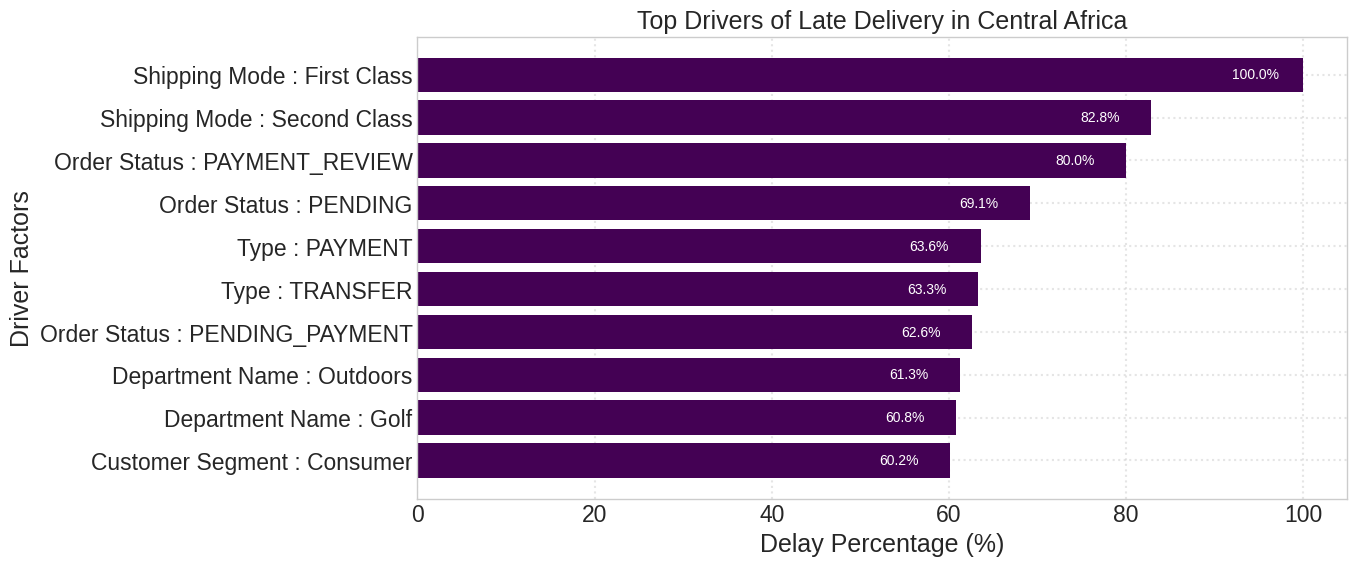

In [68]:
#Top 10 Drivers of Late Delivery in Central Africa

top_factors = top_drivers_for_region('Central Africa')
display(top_factors.round(2))

plt.figure(figsize=(12, 6))
bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'], color=primary_color)

plt.xlabel("Delay Percentage (%)")
plt.ylabel("Driver Factors")
plt.title("Top Drivers of Late Delivery in Central Africa")
plt.grid(True, linestyle=':', alpha=0.5)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 8,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va='center',
        fontsize=10,
        color='white'
    )

plt.show()

In [67]:
#Time-based analysis

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

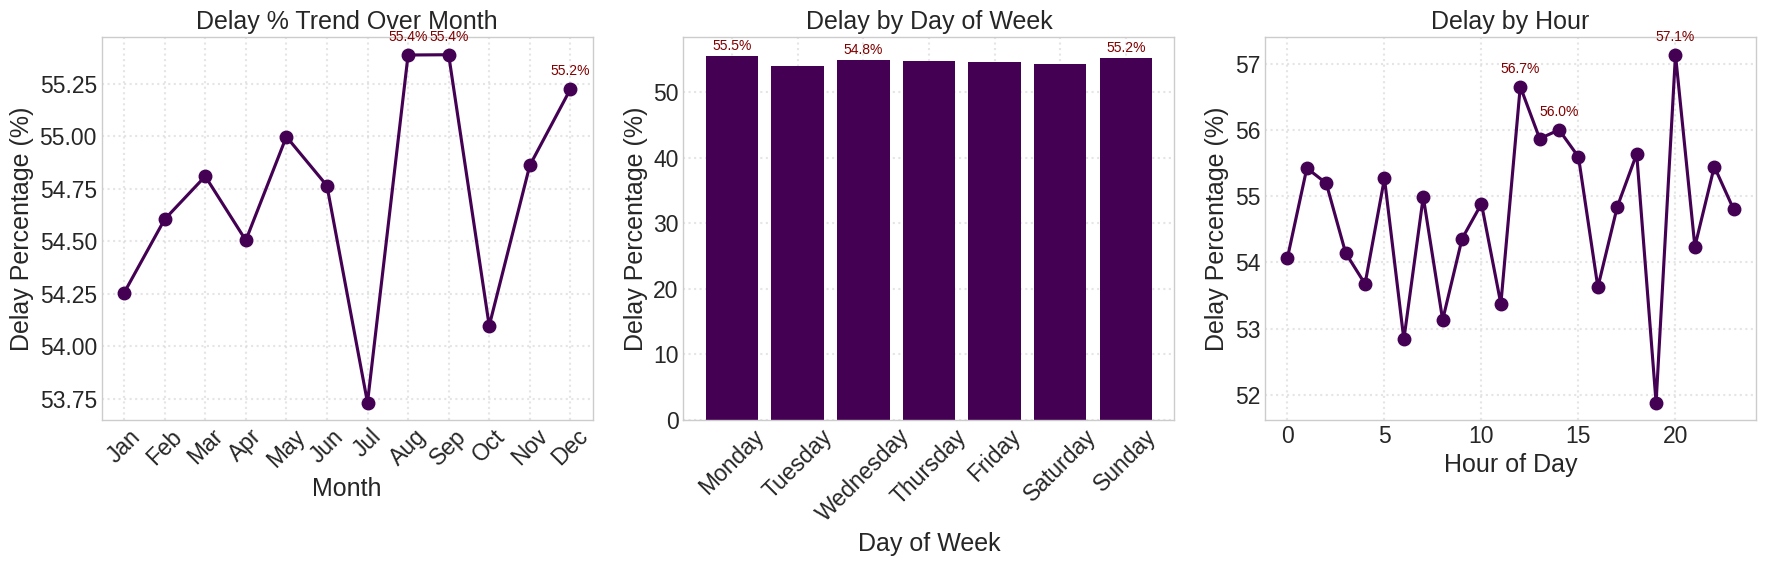

In [66]:
#Month, Day, Hour

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Month
ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    color=primary_color
)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )

# Day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    x_pos = day_order.index(row['order_day'])
    height = row['delay_pct']
    ax2.text(
        x_pos,
        height + 0.4,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color=danger_color
    )

# Hour
ax3.plot(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    marker='o',
    color=primary_color
)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_hour'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )

plt.tight_layout()
plt.show()

In [69]:
#MODELING SETUP

X = df[[
    'Type',
    'Days for shipment (scheduled)',
    'Category Name',
    'Customer Segment',
    'Department Name',
    'Order Region',
    'Shipping Mode',
    'order_month',
    'order_hour'
]].copy()

y = df['Late_delivery_risk'].copy()

print(X.head())
print(y.value_counts())

       Type  Days for shipment (scheduled)   Category Name Customer Segment  \
0     DEBIT                              4  Sporting Goods         Consumer   
1  TRANSFER                              4  Sporting Goods         Consumer   
2      CASH                              4  Sporting Goods         Consumer   
3     DEBIT                              4  Sporting Goods      Home Office   
4   PAYMENT                              4  Sporting Goods        Corporate   

  Department Name    Order Region   Shipping Mode  order_month  order_hour  
0         Fitness  Southeast Asia  Standard Class            1          22  
1         Fitness      South Asia  Standard Class            1          12  
2         Fitness      South Asia  Standard Class            1          12  
3         Fitness         Oceania  Standard Class            1          11  
4         Fitness         Oceania  Standard Class            1          11  
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: in

In [70]:
#Frequency encoding

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f"{col}_freq"] = X[col].map(freq)

X_encoded = X.drop(columns=cat_cols)

print("Shape after frequency encoding:", X_encoded.shape)

X = X_encoded.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after frequency encoding: (172765, 9)
Train shape: (138212, 9)
Test shape : (34553, 9)


In [71]:
#Impute + SMOTE

imputer = SimpleImputer(strategy='most_frequent')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imputed, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [76]:
#Evaluation helper

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n=== {model_name} ===")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall   :", round(recall_score(y_true, y_pred), 2))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

In [75]:
#Random Forest
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test_imputed)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


=== Random Forest Classifier ===
Accuracy : 0.74
Precision: 0.79
Recall   : 0.75

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553



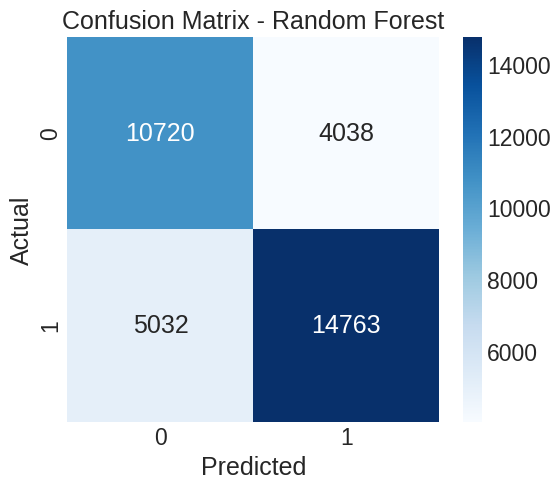

In [77]:
#Confusion matrix

cm = confusion_matrix(y_test, y_pred_rf_balanced)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [78]:
#Ringkasan hasil model

acc = accuracy_score(y_test, y_pred_rf_balanced)
precision = precision_score(y_test, y_pred_rf_balanced)
recall = recall_score(y_test, y_pred_rf_balanced)

print("Model Accuracy :", round(acc, 4))
print("Model Precision:", round(precision, 4))
print("Model Recall   :", round(recall, 4))

Model Accuracy : 0.7375
Model Precision: 0.7852
Model Recall   : 0.7458


In [79]:
#Simpan cleaned data

df.to_csv("clean_supplychain_data.csv", index=False)
print("Saved: clean_supplychain_data.csv")

Saved: clean_supplychain_data.csv


In [80]:
#Simpan top factors
top_factors.to_csv("top_10_central_africa_drivers.csv", index=False)
print("Saved: top_10_central_africa_drivers.csv")

Saved: top_10_central_africa_drivers.csv


In [81]:
#Summary otomatis

print("===== SUMMARY =====")
print(f"Total Orders       : {len(df):,}")
print(f"Late Deliveries    : {(df['Delay'] > 0).sum():,}")
print(f"Late Delivery Rate : {((df['Delay'] > 0).mean() * 100):.2f}%")
print(f"On-Time Rate       : {(100 - ((df['Delay'] > 0).mean() * 100)):.2f}%")
print(f"Profit at Risk     : ${df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum():,.2f}")
print(f"RF Accuracy        : {accuracy_score(y_test, y_pred_rf_balanced):.2%}")

===== SUMMARY =====
Total Orders       : 172,765
Late Deliveries    : 94,523
Late Delivery Rate : 54.71%
On-Time Rate       : 45.29%
Profit at Risk     : $2,055,765.16
RF Accuracy        : 73.75%
